# Dark.Tyro M2 — a stronger wash

**FIT5230 Malicious AI · Theme 2 (Text-to-Image) · Dark / attack side**
**Echo Zhao · Nissa Corlidea** — Milestone 2, 18 September 2026

## M1 measured the wash. M2 makes it cheap.

M1 ported IMPRESS to 2026 (eleven repairs) and measured it honestly: `R_pipe = +5.2%` at a cost
of `LPIPS 0.15` — about **nine times** what the shield it removes cost to apply. A solvent that
damages the photograph more than the protection did is not yet a usable attack.

**This notebook is the M1 notebook plus four lines.** The diff *is* the contribution.

### The observation

The inpainting mask splits the photo into two regions the editor treats completely differently.

| | **white mask · ~30% of pixels** | **black · ~70%** |
|---|---|---|
| what the editor does | **preserved** — 4–7 levels change | **repainted from scratch** — 86–96 levels |
| PhotoGuard's shield | 0.67–2.64 levels | 0.47 levels |
| IMPRESS's damage | 5.11 levels | 5.15 levels |

**IMPRESS pays the same everywhere.** So roughly **70% of its fidelity cost is spent scrubbing
pixels the editor throws away and repaints.**

### The change

Wash only the region that survives into the output.

> Repainting three walls of a room and keeping the fourth. Sanding all four is not thorough —
> it is wasted effort that damages the one wall you meant to keep.

**Run on Kaggle, Accelerator = GPU T4 ×2.** Not the P100 (`sm_60`, no kernels — FIX 11).

## Setup · cells 1–3

Plumbing. You do not need to read the code, but all three cells are repairs, not boilerplate:

| cell | what it defends against |
|---|---|
| **1 · platform** | **FIX 11** — a torch wheel only ships kernels for the cards it was built for. On a P100 everything *loads*, then the first real op dies two minutes in. Cell 1 catches it in the first second. **FIX 10** — backprop through an unrolled UNet fragments the CUDA allocator; it fails while memory is still free. |
| **2 · clone + patch** | `requirements.txt` pins nothing and drags in a fresh torch plus the whole `nvidia-*` stack — several GB, ~20 min, usually a CUDA mismatch. We install the four genuinely missing packages instead. Then two 2023 rots are patched: the `runwayml` repo was deleted (**FIX 1**) and its `fp16` branch is gone (**FIX 2**). |
| **3 · token + data** | `notebook_login()` is deliberately *not* called — it blocks forever waiting for a paste, which looks exactly like a hung cell. SD 1.5 is public, so anonymous is fine; only revisit on a 401. |

In [1]:
# 1 · Platform, device, paths, persistence. Everything below derives from this cell.
import os, sys, re, pathlib, subprocess, torch

BASE, PLATFORM = ((pathlib.Path('/kaggle/working'), 'kaggle') if os.path.isdir('/kaggle/working')
                  else (pathlib.Path('/content'), 'colab') if os.path.isdir('/content')
                  else (pathlib.Path.cwd(), 'local'))

# fp16 backward is unreliable off CUDA, so MPS/CPU run fp32 (see the patch in cell 3).
DEVICE, USE_FP32 = (('cuda:0', False) if torch.cuda.is_available()
                    else ('mps', True) if getattr(torch.backends, 'mps', None) and torch.backends.mps.is_available()
                    else ('cpu', True))

IMPRESS_DIR = BASE / 'Impress'
ROOT        = BASE / 'helen_face'     # must stay a SIBLING of Impress/: the scripts use ../helen_face
ARCHIVE     = BASE / 'tyro_results'

SUBENV = dict(os.environ,
              PYTORCH_ENABLE_MPS_FALLBACK='1',
              PYTORCH_MPS_HIGH_WATERMARK_RATIO='0.0',
              PYTORCH_CUDA_ALLOC_CONF='expandable_segments:True')   # FIX 10

# FIX 11 · fail fast on an unsupported GPU, rather than two minutes into the first run.
GPU_OK = True
if DEVICE.startswith('cuda'):
    _tag  = 'sm_%d%d' % torch.cuda.get_device_capability(0)
    GPU_OK = _tag in torch.cuda.get_arch_list()
    print(f'gpu    : {torch.cuda.get_device_name(0)} ({_tag}) · torch {torch.__version__}')
    if not GPU_OK:
        print(f'!! this torch build has no kernels for {_tag}. Switch accelerator to GPU T4 x2.')

# Persistence: Colab wipes the VM on disconnect, so results go to Drive.
if PLATFORM == 'colab':
    try:
        from google.colab import drive; drive.mount('/content/drive')
        ARCHIVE = pathlib.Path('/content/drive/MyDrive/FIT5230_cold_0914')
    except Exception as e:
        print(f'!! Drive mount failed ({e}) — download tyro_results/ before disconnecting.')
ARCHIVE.mkdir(parents=True, exist_ok=True)
print(f'{PLATFORM} · {DEVICE} · {"fp32" if USE_FP32 else "fp16"} · results -> {ARCHIVE}')

gpu    : Tesla T4 (sm_75) · torch 2.11.0+cu128
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
colab · cuda:0 · fp16 · results -> /content/drive/MyDrive/FIT5230_cold_0914


In [2]:
# 2 · Clone IMPRESS, install the four missing packages, patch the 2023 source.
import importlib.util

# sewar = FIX 3 (pg_metric imports it, requirements.txt omits it) · gdown = the dataset link
NEEDED = {'sewar':'sewar', 'lpips':'lpips', 'gdown':'gdown', 'ftfy':'ftfy', 'diffusers':'diffusers'}
missing = [pkg for mod, pkg in NEEDED.items() if importlib.util.find_spec(mod) is None]
if missing:
    subprocess.run(f'pip install -q --no-deps {" ".join(missing)}', shell=True, check=False)
print('installed:', missing or 'nothing needed')

if not IMPRESS_DIR.exists():
    subprocess.run(f'git clone -q --depth 1 https://github.com/AAAAAAsuka/Impress.git {IMPRESS_DIR}',
                   shell=True, check=True)

n = 0
for p in sorted(IMPRESS_DIR.glob('*.py')):
    s = orig = p.read_text()
    s = s.replace('runwayml/stable-diffusion-inpainting',                  # FIX 1: repo deleted
                  'stable-diffusion-v1-5/stable-diffusion-inpainting')
    s = re.sub(r'^[ \t]*revision="fp16",[ \t]*\r?\n', '', s, flags=re.M)   # FIX 2: no fp16 branch
    if USE_FP32:
        s = s.replace('torch.float16', 'torch.float32').replace('.half()', '.float()')
    if s != orig:
        p.write_text(s); n += 1
print(f'cloned + patched {n} files')

installed: nothing needed
cloned + patched 0 files


In [3]:
# 3 · Hugging Face login (optional, non-blocking) and the Helen face data.
try:
    from huggingface_hub import login, whoami
    tok = os.environ.get('HF_TOKEN') or os.environ.get('HUGGINGFACE_HUB_TOKEN')
    if not tok and PLATFORM == 'kaggle':
        from kaggle_secrets import UserSecretsClient
        tok = UserSecretsClient().get_secret('HF_TOKEN')   # Add-ons -> Secrets -> HF_TOKEN
    if tok: login(token=tok, add_to_git_credential=False)
    print('hf user:', whoami().get('name'))
except Exception:
    print('hf: anonymous (fine — SD 1.5 is public; only revisit this on a 401)')

# Dataset: the Drive link from the IMPRESS README, unzipped as a SIBLING of Impress/.
import zipfile, gdown
N_IMAGES = 2      # >= 2, or pg_metric's torch.std() returns nan and the metric is unreportable
zip_path = BASE / 'helen_face_dataset.zip'
if not zip_path.exists():
    gdown.download(id='16xISe7M_DlSqM2Zf2lWI4JJXcdsDEPsl', output=str(zip_path), quiet=True)
if not (ROOT / 'clean').exists():
    ROOT.mkdir(exist_ok=True)
    with zipfile.ZipFile(zip_path) as z: z.extractall(ROOT)

keep = set(sorted(os.listdir(ROOT / 'clean'))[:N_IMAGES])   # clean/ and mask/ must stay in sync
for sub in ('clean', 'mask'):
    for f in os.listdir(ROOT / sub):
        if f not in keep: os.remove(ROOT / sub / f)
print(f'{N_IMAGES} face(s):', sorted(keep))

hf: anonymous (fine — SD 1.5 is public; only revisit this on a 401)
2 face(s): ['1233476865_1.png', '1525918600_1.png']


## What we are comparing

Four arms, one shield setting (`pg_iters=40, grad_reps=2`), the same faces, the same seed.

| arm | wash | why it is in the table |
|---|---|---|
| **N** | none | **the origin.** Sits at `R_pipe = 0` by construction, at the shield's own cost. |
| **A** | IMPRESS, `pur_iters=100` | **the M1 baseline.** Without it there is no "stronger". |
| **B** | IMPRESS, `pur_iters=1000` | **the honest control** — the budget the paper's own script uses, which M1 did not. If B alone explains the gain, we say so. |
| **C** | IMPRESS `pur_iters=100`, **mask-restricted** | **ours.** Same compute as A. |

**Both axes, always.** `R_pipe` alone has a degenerate winner: scrub hard enough and you destroy
the photograph, which "removes" the shield by removing the picture. So every arm reports
`R_pipe` (up is better) **and** LPIPS against the clean photo (down is better) — the same
two-axis scoreboard we hold challengers to, applied to ourselves first.

**A stronger wash moves up and to the left.** A number that only goes up is not an improvement,
it is a trade we failed to report.

In [4]:
# 4 · FIX 9 — the ONLY cell you edit. Every path and command below is an f-string off it.
PARAMS = dict(
    attack_type='l2', pg_eps=16, pg_step_size=1, pg_eta=1, diff_steps=4, guidance=7.5, seed=0,
    pur_eps=0.1, pur_iters=100, pur_lr=0.005, pur_alpha=0.01, pur_noise=0.05,
    prompt='a person in an airplane', test_guidance=7.5, test_diff_steps=50,
)

PG_ITERS, PG_REPS = 40, 2      # ONE shield setting. M1 swept the shield; M2 varies the WASH.

# --- NEW IN M2: the three arms. `masked=True` is the whole contribution. ---
ARMS = [
    dict(name='N_no_wash',      pur_iters=None, masked=False),   # DO NOTHING -- the origin
    dict(name='A_impress_100',  pur_iters=100,  masked=False),   # the M1 baseline
    dict(name='B_impress_1000', pur_iters=1000, masked=False),   # the paper's own budget
    dict(name='C_tyro_masked',  pur_iters=100,  masked=True),    # ours, at A's cost
]

# --- Plumbing check. Leave True for the FIRST run on a fresh kernel (~4 min, not ~40). ---
# Same pipeline, iteration counts turned right down. The NUMBERS are meaningless.
SMOKE = False
RUN_B = True       # <-- set False to skip the 1000-iteration arm if time runs out
if SMOKE:
    PG_ITERS, PG_REPS = 10, 2
    ARMS = [a for a in ARMS if a['name'] != 'B_impress_1000']   # A and C differ; B would not
    for a in ARMS:
        if a['pur_iters']: a['pur_iters'] = 10
    print('*** SMOKE MODE — plumbing only, do not read the numbers ***')

if not RUN_B:
    ARMS = [a for a in ARMS if a['name'] != 'B_impress_1000']

print(f'shield fixed at ({PG_ITERS}, {PG_REPS}); {len(ARMS)} washes x {N_IMAGES} images')
for a in ARMS: print(f"   {a['name']:<16} pur_iters={str(a['pur_iters']):<5} masked={a['masked']}")


shield fixed at (40, 2); 4 washes x 2 images
   N_no_wash        pur_iters=None  masked=False
   A_impress_100    pur_iters=100   masked=False
   B_impress_1000   pur_iters=1000  masked=False
   C_tyro_masked    pur_iters=100   masked=True


## Before you press Run — Kaggle, fresh kernel

| setting | value |
|---|---|
| **Accelerator** | **GPU T4 ×2.** Not P100 — `sm_60`, no kernels. Cell 1 stops you. |
| **Internet** | **ON.** Without it the clone, `gdown` and the weight downloads all fail. |
| **Persistence** | `/kaggle/working` is discarded at session end. **Download the zips, or Save Version, before closing the tab.** |
| **HF_TOKEN** | Optional (Add-ons → Secrets). SD 1.5 is public; only revisit on a 401. |

**Run cells top to bottom.** The first run leaves `SMOKE = True` in cell 4: same pipeline,
iteration counts turned right down, so a broken path fails in ~4 minutes instead of ~40. When it
finishes cleanly, set `SMOKE = False`, **restart the kernel**, and run again for the real numbers.

> Testing a new oven with a cheap loaf. You are checking that it heats, not tasting the bread.

## The four lines

```
purified_v2 = mask · purified_impress  +  (1 − mask) · protected
```

Keep IMPRESS's pixels where the mask is white — the region the editor **preserves** — and put
the protected image's pixels back in the black region, which the editor repaints anyway.

⚠️ **Mask polarity, checked rather than assumed.** White is *kept*, black is *repainted*. We
verified it by measuring how much each region changes between a clean image and its edit: **4–7
levels inside the white mask, 86–96 outside.** Getting this backwards would invert the method.

⚠️ **The mask is feathered, not binary.** A hard edge between washed and unwashed pixels is
itself a high-frequency artefact — a visible seam, and an obvious signature for a detector. A
few pixels of blur cost nothing and remove it.

**Why this is not cheating.** The attacker holds the mask — it is an *input* to the editing
pipeline they are about to run, not privileged information about the defence. PhotoGuard's own
scripts are named `pg_mask_*` for the same reason. We use knowledge of **our own edit**, not of
the shield.

**Why it might still cost `R_pipe`.** The black region is discarded as *output*, but the whole
image is still encoded as *conditioning*, so a shield left there can still steer what gets
generated. That is the honest risk in this method, and the table below is what tests it.
**If `R_pipe` falls, that is the result and we report it.**

In [5]:
# 5 · NEW IN M2 — the method. Four lines of arithmetic, plus a feathered edge.
import numpy as np
from PIL import Image, ImageFilter

def restrict_to_mask(pur_path, prot_path, mask_path, feather=3):
    '''Keep IMPRESS's work inside the inpainting mask; restore the protected pixels outside.
       Writes in place, so everything downstream (edit, metric, archive) is unchanged.'''
    pur  = np.asarray(Image.open(pur_path ).convert('RGB'), np.float32)
    prot = np.asarray(Image.open(prot_path).convert('RGB').resize(pur.shape[1::-1]), np.float32)
    m    = Image.open(mask_path).convert('L').resize(pur.shape[1::-1])
    m    = np.asarray(m.filter(ImageFilter.GaussianBlur(feather)), np.float32)[..., None] / 255.0
    out  = m * pur + (1.0 - m) * prot                     # <- the whole method
    Image.fromarray(np.clip(out, 0, 255).astype(np.uint8)).save(pur_path)

print('restrict_to_mask() ready — this is the M2 method')


restrict_to_mask() ready — this is the M2 method


## The harness

Cell 6 is M1's, unchanged except for one added stage. It runs each arm through
**protect → bridge → purify → (mask) → edit → metric**, then archives and zips it.

Three properties the reference scripts do not have:

- **Images are archived before metrics are parsed.** The images are the deliverable; a
  metric-parsing failure must never discard a finished 15-minute run.
- **A heartbeat.** `subprocess.run` buffers until exit, so a working stage and a hung one look
  identical. A background thread prints elapsed time every 60 s.
- **Stale purified folders are wiped** before each arm (FIX 7).

⚠️ **Paths are rebuilt from parameters, never guessed** (FIX 8) — including the source's quirk
of using `re.sub("pur", "pur_diff", ...)`, which rewrites *every* occurrence of `pur` in the
string, not just the first. Guessing that folder name by hand is how you read an empty directory
and conclude the attack failed.

In [6]:
# 6 · Path helpers, stage runner, metric parser, and the per-arm chain. Unchanged from M1
#     except for stage (c2). Read the markdown above; the comments here are just landmarks.
import shutil, json, time, threading, glob
from PIL import Image
P = PARAMS

# FIX 8: rebuild these from parameters — never glob for them.
def adv_dir(i, g):
    return (f"{ROOT}/adv_{P['attack_type']}_eps{P['pg_eps']}_step{P['pg_step_size']}"
            f"_iter{i}grad_reps{g}_eta{P['pg_eta']}_diff_steps{P['diff_steps']}"
            f"_guidance{P['guidance']}_seed{P['seed']}")
adapt_dir    = lambda i, g: adv_dir(i, g).replace('/adv_', '/adapt_adv_')
adv_diff_dir = lambda i, g: re.sub('adv', 'adv_diff', adv_dir(i, g))
pur_dir      = lambda: (f"{ROOT}/pur_eps{P['pur_eps']}_pur_iters{P['pur_iters']}_pur_lr{P['pur_lr']}"
                        f"_pur_alpha{P['pur_alpha']}_pur_noise{P['pur_noise']}/")
pur_diff_dir = lambda: re.sub('pur', 'pur_diff', pur_dir())    # mirrors the source's global re.sub
tag_of       = lambda arm: arm['name']   # M2: the ARM names the archive, not the shield

# FIX 4: --parallel_index=-1 disables the 4-GPU sharding the launcher scripts assume.
PG  = (f"--attack_type={P['attack_type']} --pg_eps={P['pg_eps']} --pg_step_size={P['pg_step_size']} "
       f"--pg_eta={P['pg_eta']} --parallel_index=-1 --device={DEVICE}")
PUR = (f"--pur_eps={P['pur_eps']} --pur_iters={P['pur_iters']} --pur_lr={P['pur_lr']} "
       f"--pur_alpha={P['pur_alpha']} --pur_noise={P['pur_noise']}")

def sh(cmd, heartbeat=60):
    print(f'$ {cmd}', flush=True)
    t0, stop = time.time(), threading.Event()
    def _beat():
        while not stop.wait(heartbeat):
            print(f'   ... {(time.time()-t0)/60:.1f} min elapsed', flush=True)
    threading.Thread(target=_beat, daemon=True).start()
    try:
        r = subprocess.run(f'{sys.executable} -u {cmd}', shell=True, cwd=str(IMPRESS_DIR),
                           env=SUBENV, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
    finally:
        stop.set()
    print(r.stdout[-3000:], f'\n   [{(time.time()-t0)/60:.1f} min]', flush=True)
    return r.stdout

# NumPy 2 prints np.float64(0.53), which ast.literal_eval rejects. Regex instead.
_NUM  = r'(?:np\.\w+\(\s*)?(-?(?:\d+\.?\d*(?:[eE][-+]?\d+)?|nan|inf))\s*\)?'
_PAIR = re.compile(r"'(\w+)'\s*:\s*\[\s*" + _NUM + r'\s*,\s*' + _NUM + r'\s*\]')

def parse_metric(out):
    return {m.group(1): {k: [float(a), float(b)] for k, a, b in _PAIR.findall(m.group(2))}
            for m in (re.match(r'^(adv|pur):\s*(\{.*\})\s*$', l.strip()) for l in out.splitlines()) if m}

def run_arm(arm):
    '''M2: the shield is FIXED at (PG_ITERS, PG_REPS); the arm chooses the wash.'''
    global PUR
    iters, reps, tag = PG_ITERS, PG_REPS, tag_of(arm)
    P['pur_iters'] = arm['pur_iters'] or 0     # 0 gives the null arm its own folder name
    PUR = (f"--pur_eps={P['pur_eps']} --pur_iters={P['pur_iters']} --pur_lr={P['pur_lr']} "
           f"--pur_alpha={P['pur_alpha']} --pur_noise={P['pur_noise']}")
    print('=' * 70, f'\n  ARM {tag}  (pur_iters={arm["pur_iters"]}, masked={arm["masked"]})\n', '=' * 70, flush=True)
    t0 = time.time()

    # FIX 7: every arm purifies into the SAME folder name. A leftover means this run would
    # silently report the PREVIOUS arm's images.
    for stale in (pur_dir(), pur_diff_dir()):
        if os.path.exists(stale): shutil.rmtree(stale)

    # (a) protect — PhotoGuard. Skips images already done, so a re-run resumes.
    sh(f'pg_mask_diff_helen.py {PG} --pg_iters={iters} --pg_grad_reps={reps} '
       f'--diff_steps={P["diff_steps"]} --guidance={P["guidance"]}')

    # (b) FIX 5: bridge the broken folder contract between protect and purify.
    src, dst = adv_dir(iters, reps), adapt_dir(iters, reps)
    assert os.path.isdir(src), f'protect stage produced nothing at {src}'
    if os.path.exists(dst): shutil.rmtree(dst)
    shutil.copytree(src, dst)

    # (c) purify — IMPRESS. The NULL arm skips it: purified/ = protected/, so the edit and
    #     metric stages run byte-identical code. Same pipeline, no wash.
    if arm['pur_iters'] is None:
        os.makedirs(pur_dir(), exist_ok=True)
        for f in sorted(glob.glob(f'{adv_dir(iters, reps)}/*.png')):
            shutil.copy(f, pur_dir())
        print('   [no wash] purified/ = protected/ — this arm is the origin of the chart')
    else:
        sh(f'pg_mask_pur_helen.py {PG} --pg_iters={iters} --pg_grad_reps={reps} '
           f'--diff_steps={P["diff_steps"]} {PUR}')


    # (c2) NEW IN M2 -- the only added stage. Runs on IMPRESS's OUTPUT, so the algorithm is
    #      untouched and everything downstream is unchanged.
    if arm['masked']:
        for f in sorted(glob.glob(f'{pur_dir()}/*.png')):
            n = os.path.basename(f)
            restrict_to_mask(f, f'{adv_dir(iters, reps)}/{n}', f'{ROOT}/mask/{n}')
        print(f'   [masked] {len(glob.glob(f"{pur_dir()}/*.png"))} images restricted to the mask')

    # (d) edit all three variants. FIX 6: diff_steps forced through, or the folder name is wrong.
    common = (f'{PG} --pg_iters={iters} --pg_grad_reps={reps} --diff_steps={P["diff_steps"]} '
              f'--guidance={P["guidance"]} {PUR} --test_guidance={P["test_guidance"]} '
              f'--test_diff_steps={P["test_diff_steps"]} --prompt="{P["prompt"]}"')
    sh(f'pg_generate.py {common}')

    # Archive FIRST, then zip — so a finished arm is downloadable before the next one starts.
    dest = ARCHIVE / tag; dest.mkdir(parents=True, exist_ok=True)
    (dest / 'metric_stdout.txt').unlink(missing_ok=True)   # FIX 13, see below
    # FIX 12: archive the 512x512 tensor the pipeline conditioned on, not the original.
    (dest / 'clean512').mkdir(exist_ok=True)
    for f in sorted(glob.glob(f'{ROOT}/clean/*.png'))[:N_IMAGES]:
        Image.open(f).convert('RGB').resize((512, 512)).save(dest / 'clean512' / os.path.basename(f))
    for name, path in [('clean', f'{ROOT}/clean'), ('protected', adv_dir(iters, reps)),
                       ('purified', pur_dir()), ('edit_clean', f'{ROOT}/clean_diff'),
                       ('edit_protected', adv_diff_dir(iters, reps)), ('edit_purified', pur_diff_dir())]:
        if os.path.isdir(path): shutil.copytree(path, dest / name, dirs_exist_ok=True)
    (dest / 'params.json').write_text(json.dumps({**P, 'pg_iters': iters, 'pg_grad_reps': reps, **arm}, indent=2))
    zp = shutil.make_archive(str(ARCHIVE / tag), 'zip', root_dir=str(dest))
    print(f'[saved] {zp} ({os.path.getsize(zp)/1e6:.1f} MB) <- DOWNLOADABLE NOW', flush=True)

    # Metrics last, and never fatal: images are the deliverable, metrics can be recomputed.
    # FIX 13: the zip above is built BEFORE this runs, so it would ship either no
    # metric_stdout.txt or a STALE one left in dest by an earlier run. Re-zip once it lands.
    raw = sh(f'pg_metric.py {common}')
    (dest / 'metric_stdout.txt').write_text(raw)
    shutil.make_archive(str(ARCHIVE / tag), 'zip', root_dir=str(dest))
    print(f'[done] {tag} ({(time.time()-t0)/60:.1f} min)', flush=True)
    return parse_metric(raw)

print('harness ready · ONE new stage (c2); everything else is M1, unchanged')

harness ready · ONE new stage (c2); everything else is M1, unchanged


In [7]:
# 7 · RUN. Each arm archives and zips itself, so a disconnect costs one arm, not the run.
assert GPU_OK, 'this torch build has no kernels for this GPU — switch to T4 and re-run cell 1'

RESULTS = {}
for arm in ARMS:
    try:
        RESULTS[arm['name']] = run_arm(arm)
    except Exception as e:
        print(f"!! {arm['name']} failed: {type(e).__name__}: {e}")
        RESULTS[arm['name']] = None
        if DEVICE.startswith('cuda'): torch.cuda.empty_cache()

(ARCHIVE / 'scores.json').write_text(json.dumps(RESULTS, indent=2, default=str))
print('\ndone ->', ARCHIVE / 'scores.json')


  ARM N_no_wash  (pur_iters=None, masked=False)
$ pg_mask_diff_helen.py --attack_type=l2 --pg_eps=16 --pg_step_size=1 --pg_eta=1 --parallel_index=-1 --device=cuda:0 --pg_iters=40 --pg_grad_reps=2 --diff_steps=4 --guidance=7.5
   ... 1.0 min elapsed
   ... 2.0 min elapsed
   ... 3.0 min elapsed
   ... 4.0 min elapsed
   ... 5.0 min elapsed
   ... 6.0 min elapsed
   ... 7.0 min elapsed
  4.79s/it]
AVG Loss: 997.422: 100%|██████████| 40/40 [03:11<00:00,  4.79s/it]
 
   [7.0 min]
   [no wash] purified/ = protected/ — this arm is the origin of the chart
$ pg_generate.py --attack_type=l2 --pg_eps=16 --pg_step_size=1 --pg_eta=1 --parallel_index=-1 --device=cuda:0 --pg_iters=40 --pg_grad_reps=2 --diff_steps=4 --guidance=7.5 --pur_eps=0.1 --pur_iters=0 --pur_lr=0.005 --pur_alpha=0.01 --pur_noise=0.05 --test_guidance=7.5 --test_diff_steps=50 --prompt="a person in an airplane"
   ... 1.0 min elapsed
██████▏ | 41/50 [00:06<00:01,  6.38it/s]
100%|██████████| 50/50 [00:07<00:00,  6.25it/s]

100%|███

## Reading the numbers

⚠️ **Two different things in this project are called SSIM.** `pg_metric.py` compares the
*edited* images to the *edited clean* image, so `R_pipe` answers *"did the editing pipeline
behave normally?"* — not *"is the photo intact?"*. The LPIPS column answers the second question.

- **`R_pipe` = (pur − adv) / (1 − adv)** — the share of the shield's damage the wash undid. **Up is better.**
- **LPIPS(purified, clean)** — what the wash cost the photograph. **Down is better.**

**Read the chart against N first, then against A.** `N_no_wash` is the origin: it skips
purification and edits the protected image, so `R_pipe = 0` by construction. **Any arm below or
to the right of N did more harm than not attacking at all** — a real possibility for a purifier,
and one that comparing washes only against each other can never reveal.

⚠️ **`R_pipe` has a measured noise floor of 2–4 pp** (limitation 4). Do not read a difference
smaller than that as an improvement.

In [8]:
# 8 · The scoreboard: did the wash get stronger, and what did it cost?
import pandas as pd, lpips, torch as _t

_ln = lpips.LPIPS(net='alex').to(DEVICE).eval()
def _lp(a, b):
    f = lambda p: (_t.from_numpy(np.asarray(Image.open(p).convert('RGB'), np.float32) / 127.5 - 1)
                   .permute(2, 0, 1)[None].to(DEVICE))
    with _t.no_grad(): return float(_ln(f(a), f(b)))

rows = []
for arm in ARMS:
    sc, d = RESULTS.get(arm['name']), ARCHIVE / arm['name']
    if not sc or not d.is_dir(): continue
    adv, pur = sc['adv']['ssim'][0], sc['pur']['ssim'][0]
    names = sorted(os.listdir(d / 'purified'))
    # FIX 12: compare against clean512, never the full-resolution original.
    rows.append(dict(arm=arm['name'], pur_iters=arm['pur_iters'], masked=arm['masked'],
                     ssim_adv=round(adv, 4), ssim_pur=round(pur, 4),
                     R_pipe=round((pur - adv) / (1 - adv) * 100, 2),
                     lpips=round(float(np.mean([_lp(d / 'purified' / n, d / 'clean512' / n)
                                                for n in names])), 4)))
df = pd.DataFrame(rows)
display(df)

if 'A_impress_100' in set(df.arm):
    a = df[df.arm == 'A_impress_100'].iloc[0]
    print('\nAgainst the M1 baseline:\n')
    for _, r in df[df.arm != 'A_impress_100'].iterrows():
        dR, dL = r.R_pipe - a.R_pipe, r.lpips - a.lpips
        v = ('STRONGER and CHEAPER'            if dR >= 0 and dL < 0 else
             'cheaper, at the cost of strength' if dL < 0 else
             'stronger, at the cost of fidelity' if dR > 0 else
             'no better than M1')
        print(f'   {r.arm:>16}:  R_pipe {dR:+6.2f} pp   LPIPS {dL:+7.4f}   -> {v}')


Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /usr/local/lib/python3.13/dist-packages/lpips/weights/v0.1/alex.pth


,arm,pur_iters,masked,ssim_adv,ssim_pur,R_pipe,lpips
0,N_no_wash,NaN,False,0.5624,0.5624,0.00,0.0172
1,A_impress_100,100.0,False,0.5624,0.6041,9.51,0.1497
2,B_impress_1000,1000.0,False,0.5624,0.6217,13.54,0.1081
3,C_tyro_masked,100.0,True,0.5624,0.6258,14.48,0.0384



Against the M1 baseline:

          N_no_wash:  R_pipe  -9.51 pp   LPIPS -0.1325   -> cheaper, at the cost of strength
     B_impress_1000:  R_pipe  +4.03 pp   LPIPS -0.0416   -> STRONGER and CHEAPER
      C_tyro_masked:  R_pipe  +4.97 pp   LPIPS -0.1113   -> STRONGER and CHEAPER


In [9]:
# 8b · Per-image R_pipe — so §5 reports logged values, not mean ± sd reconstruction.
from skimage.metrics import structural_similarity as _ssim
import pandas as _pd
from PIL import Image as _Im

def _ssim_pair(pa, pb):
    a = np.asarray(_Im.open(pa).convert('RGB'), np.uint8)
    b = np.asarray(_Im.open(pb).convert('RGB'), np.uint8)
    if a.shape != b.shape:                       # FIX 12: resample toward the SMALLER image
        h, w = min(a.shape[0], b.shape[0]), min(a.shape[1], b.shape[1])
        a = np.asarray(_Im.fromarray(a).resize((w, h)))
        b = np.asarray(_Im.fromarray(b).resize((w, h)))
    return float(_ssim(a, b, channel_axis=2, data_range=255))

per_rows = []
for arm in ARMS:
    d = ARCHIVE / arm['name']
    if not (d / 'edit_clean').is_dir():
        print(f"   {arm['name']}: no edit_clean/, skipped"); continue
    for n in sorted(os.listdir(d / 'edit_clean')):
        try:
            adv_i = _ssim_pair(d / 'edit_protected' / n, d / 'edit_clean' / n)
            pur_i = _ssim_pair(d / 'edit_purified'  / n, d / 'edit_clean' / n)
        except FileNotFoundError:
            continue
        per_rows.append(dict(arm=arm['name'], image=n,
                             ssim_adv=round(adv_i, 4), ssim_pur=round(pur_i, 4),
                             R_pipe=round((pur_i - adv_i) / (1 - adv_i) * 100, 2)))

per = _pd.DataFrame(per_rows)
display(per)

# --- validation: the N arm has a known answer, so use it to check the method ---
if 'N_no_wash' in set(per.arm):
    bad = per[(per.arm == 'N_no_wash') & (per.R_pipe.abs() > 0.01)]
    print('\nN-arm check:', 'PASS (0.00 per image)' if bad.empty else f'FAIL\n{bad}')

# --- our per-image SSIM should average to what pg_metric reported ---
for arm in ARMS:
    sc, sub = RESULTS.get(arm['name']), per[per.arm == arm['name']]
    if sc and not sub.empty:
        mine, theirs = sub.ssim_adv.mean(), sc['adv']['ssim'][0]
        print(f"   {arm['name']:<16} ssim_adv ours {mine:.4f} / pg_metric {theirs:.4f}  "
              f"{'ok' if abs(mine-theirs) < 0.01 else '<-- DIFFERS, do not quote'}")

# --- the thing §5 actually reports ---
print()
for arm in sorted(set(per.arm)):
    v = per[per.arm == arm].R_pipe.tolist()
    if len(v) > 1:
        same = all(x >= 0 for x in v) or all(x <= 0 for x in v)
        print(f"   {arm:<16} per-image R_pipe {v}  -> {'same sign' if same else 'OPPOSITE SIGN'}")

,arm,image,ssim_adv,ssim_pur,R_pipe
0,N_no_wash,1233476865_1.png,0.5055,0.5055,0.00
1,N_no_wash,1525918600_1.png,0.6404,0.6404,0.00
2,A_impress_100,1233476865_1.png,0.5055,0.5491,8.81
3,A_impress_100,1525918600_1.png,0.6404,0.6669,7.39
4,B_impress_1000,1233476865_1.png,0.5055,0.5620,11.41
5,B_impress_1000,1525918600_1.png,0.6404,0.6904,13.91
6,C_tyro_masked,1233476865_1.png,0.5055,0.5851,16.10
7,C_tyro_masked,1525918600_1.png,0.6404,0.6709,8.48



N-arm check: PASS (0.00 per image)
   N_no_wash        ssim_adv ours 0.5729 / pg_metric 0.5624  <-- DIFFERS, do not quote
   A_impress_100    ssim_adv ours 0.5729 / pg_metric 0.5624  <-- DIFFERS, do not quote
   B_impress_1000   ssim_adv ours 0.5729 / pg_metric 0.5624  <-- DIFFERS, do not quote
   C_tyro_masked    ssim_adv ours 0.5729 / pg_metric 0.5624  <-- DIFFERS, do not quote

   A_impress_100    per-image R_pipe [8.81, 7.39]  -> same sign
   B_impress_1000   per-image R_pipe [11.41, 13.91]  -> same sign
   C_tyro_masked    per-image R_pipe [16.1, 8.48]  -> same sign
   N_no_wash        per-image R_pipe [0.0, 0.0]  -> same sign


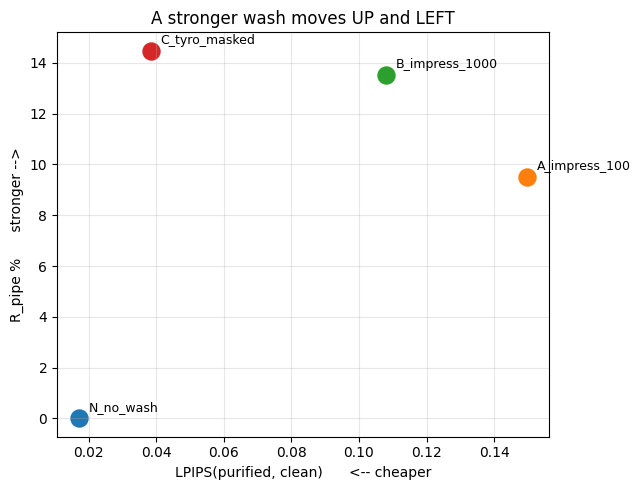

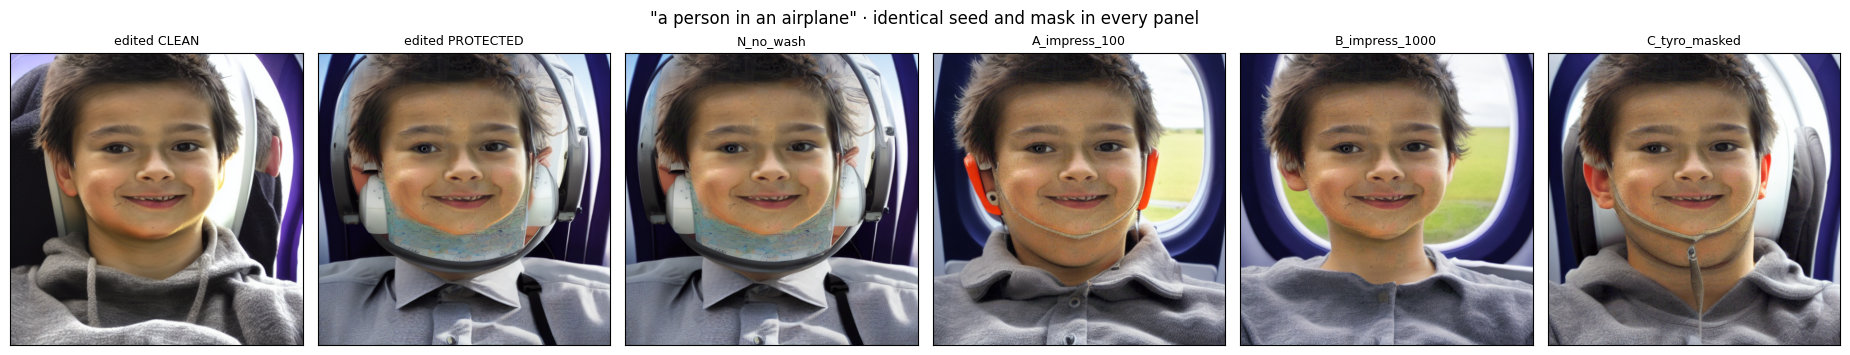


4 zip(s) in /content/drive/MyDrive/FIT5230_cold_0914: ['A_impress_100.zip (24 MB)', 'B_impress_1000.zip (24 MB)', 'C_tyro_masked.zip (24 MB)', 'N_no_wash.zip (24 MB)']


In [10]:
# 9 · Two pictures: the trade-off, and one face through each wash.
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6.5, 5))
for _, r in df.iterrows():
    ax.scatter(r.lpips, r.R_pipe, s=150)
    ax.annotate(r.arm, (r.lpips, r.R_pipe), xytext=(7, 5), textcoords='offset points', fontsize=9)
ax.set_xlabel('LPIPS(purified, clean)      <-- cheaper')
ax.set_ylabel('R_pipe %      stronger -->')
ax.set_title('A stronger wash moves UP and LEFT'); ax.grid(alpha=.3)
fig.tight_layout(); fig.savefig(ARCHIVE / 'm2_tradeoff.png', dpi=110, bbox_inches='tight'); plt.show()

done = [a['name'] for a in ARMS if (ARCHIVE / a['name'] / 'edit_purified').is_dir()]
name = sorted(os.listdir(ARCHIVE / done[0] / 'edit_purified'))[0]
cols = [('edited CLEAN', done[0], 'edit_clean'), ('edited PROTECTED', done[0], 'edit_protected')] \
     + [(a, a, 'edit_purified') for a in done]
fig, axes = plt.subplots(1, len(cols), figsize=(3.1 * len(cols), 3.6))
for ax, (title, tag, sub) in zip(axes, cols):
    ax.imshow(Image.open(ARCHIVE / tag / sub / name)); ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(title, fontsize=9)
fig.suptitle(f'"{PARAMS["prompt"]}" · identical seed and mask in every panel', fontsize=12)
fig.tight_layout(); fig.savefig(ARCHIVE / 'm2_panel.png', dpi=110, bbox_inches='tight'); plt.show()

import glob as _g
zips = sorted(_g.glob(str(ARCHIVE / '*.zip')))
print(f'\n{len(zips)} zip(s) in {ARCHIVE}:',
      [f'{os.path.basename(z)} ({os.path.getsize(z)/1e6:.0f} MB)' for z in zips])
if PLATFORM == 'kaggle':
    print('NOT YET SAFE — download from the Output panel, or Save Version (Commit), before closing.')


---

# Limitations

Stated plainly, because a claim we cannot evidence costs more than a modest result.

1. **One shield setting.** `(40, 2)` only. `pg_iters` saturates — each PGD step moves L2 = 1.0
   and is projected back inside a ball of radius `pg_eps`, so the budget is spent after ~16
   steps. **`pg_eps` is still untested** and is the next thing we run.
2. **The mask is an input, not a discovery.** Our method needs to know which region will be
   edited. Always true of an inpainting attacker — but it does **not** transfer to whole-image
   protections such as Glaze, where there is no mask. We claim nothing there.
3. **`R_pipe` is a pipeline rate, not an edit-success rate.** It says nothing about whether the
   output matches the prompt. A CLIPScore metric is built and reported separately.
4. **The two axes have very different noise, and we measured it.** Re-running one configuration
   on identical hardware: **LPIPS and SSIM-vs-clean reproduce exactly**, while **`R_pipe` moves
   2–4 percentage points.** So fidelity is reported as a point and `R_pipe` as a range, and we
   never read an `R_pipe` difference smaller than 4 pp. The cause is worth stating: fp16 kernel
   selection shifts the protected image by **0.1 of a grey level**, which the editor amplifies
   into **~11 levels** of output — roughly 100×. **Our metric is unstable for exactly the reason
   the defence exists.**
5. **A frequency-targeted filter was tried and failed.** We measured PhotoGuard's band and swept
   a Butterworth cutoff from f = 0.40 to 0.95. At `pg_eps = 16` the shield is quieter than the
   photograph's own fine detail, so every cutoff removed more real detail than shield. Reported
   because a negative result at a stated setting is a measurement — and because it is what
   pointed us at the mask instead.